# 🌼 Projet : Classification des fleurs par Deep Learning

Ce projet a pour objectif de concevoir un système capable de reconnaître automatiquement différentes espèces de fleurs à partir d’images, en utilisant des techniques de deep learning.

Les étapes principales du projet sont :
- le $découpage$ des données en ensembles d'entraînement, validation et test,
- la construction d’un $modèle$ $CNN$ (réseau de neurones convolutionnel),
- l’amélioration des performances par **$transfert de connaissances$** avec le modèle $VGG16$,
- l’évaluation du modèle à l’aide de métriques classiques (précision, matrice de confusion),
- et enfin, la création d’une **application web interactive** avec Streamlit permettant de tester le modèle en téléversant une image.

  ---
---

-  🎓 **Réalisé par :** <br>
<br>
          **$KABOU$ $Abdeldjalil$**<br>

## **Lire les données**: 
- Nos images sont stockés dans des dossiers selon leurs classes. Donc nous allons créer les bases d’apprentissage, de validation et de test

## **1. Importation des bibliothèques** 

In [ ]:
import splitfolders
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

- $splitfolders$  : pour diviser automatiquement le dataset en train/validation/test.
- $ImageDataGenerator$ : pour charger et prétraiter les images.
- $layers$, $models$ : pour créer l’architecture du CNN.

## **2. Découpage des données**

- Lire les images depuis le dossier $Donnees$ <br>
- Les répartir automatiquement en $80$% train, $10$% validation, $10$% test <br>
- Générer une nouvelle structure dans $flower_output$

In [ ]:
splitfolders.ratio(
    r"F:\Université de Toulouse\Je suis en France\Cours\S8\BE Apprentissage automatique (Machine learning)\Projet\Donnees",
    output= r"F:\Université de Toulouse\Je suis en France\Cours\S8\BE Apprentissage automatique (Machine learning)\Projet\flower_output",
    seed=1337,
    ratio=(.8, 0.1, 0.1)
)

## **3. Définition des répertoires**

In [ ]:
train_dir = r"F:\Université de Toulouse\Je suis en France\Cours\S8\BE Apprentissage automatique (Machine learning)\Projet\flower_output\train"
val_dir = r"F:\Université de Toulouse\Je suis en France\Cours\S8\BE Apprentissage automatique (Machine learning)\Projet\flower_output\val"
test_dir = r"F:\Université de Toulouse\Je suis en France\Cours\S8\BE Apprentissage automatique (Machine learning)\Projet\flower_output\test"

- Ces variables stockent les chemins vers les images d’entraînement, de validation et de test.

## **4. Création des Data Generators**
**a. Générateur pour le test**

In [ ]:
test_rescal=ImageDataGenerator(rescale=1./255)
test_gen=test_rescal.flow_from_directory(
    directory=test_dir,                      
    target_size=(180, 180),          
    color_mode='rgb',                 
    class_mode='categorical',          
    batch_size=32,                  
    shuffle=False,
    seed=None,
)

- Toutes les images sont $redimensionnées$ à 180×180.<br>
- Les pixels sont $normalisés$ entre 0 et 1 ($rescale$=1./255).<br>
- class_mode=$'categorical'$ : les étiquettes sont one-hot encodées ($donne$ $un$ $vecteur$ $one$-$hot$ $comme$ $[0, 0, 1]$) car il y a plusieurs classes (102).**<br>
- $shuffle=True$ : l’ordre des images est mélangé.

**b. Générateur pour train** <br>
- Même principe que le générateur test, mais ici utilisé pour $l'entraînement$.

In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
    directory=train_dir,
    target_size=(180, 180),
    color_mode='rgb',                 
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=2,

**c. Générateur pour validation**
- Même principe, mais ici utilisé pour $la$ $validation$

In [ ]:
val_datagen = ImageDataGenerator(rescale=1./255)
val_generator = val_datagen.flow_from_directory(
    directory=val_dir,
    target_size=(180, 180),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
        seed=2,

**Notion de $shuffle$ = $True$ ou $False$** 
- Pour $l'entraînement$ :
Nous avons utilisé $shuffle$ = $True$ pour mélanger les images à chaque époque durant l'entraînement. Cela permet d'éviter que le modèle n'apprenne simplement l'ordre des données et favorise une meilleure généralisation sinon il pourrait $sur$-$apprendre$.
- Pour $le$ $test$ :
Nous avons mis $shuffle$ = $False$ car nous voudrons savoir exactement quelle image est à quelle position (Pour que le modèle ne mémorise pas l’ordre). Sinon, tu ne peux pas comparer les prédictions à la bonne classe.

## 5. Création du modèle CNN
- Nous avons utilisé un modèle $CNN$ (Convolutional Neural Network) car ce type de réseau est particulièrement efficace pour le traitement d’images. Grâce aux couches de convolution, le $CNN$ apprend automatiquement à détecter des motifs visuels (comme les contours, les textures ou les formes) caractéristiques de chaque type de fleur. Il est capable de reconnaître ces motifs quelle que soit leur position dans l’image, ce qui le rend idéal pour la classification d’images.

In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(180, 180, 3)),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

- Nous avons construit un modèle $CNN$ composé de trois couches convolutives avec 32, 64 et 128 filtres respectivement. Chaque couche apprend à détecter des motifs visuels de plus en plus complexes :<br>
        $-$ la première repère des $bords$ et $lignes$,<br>
        $-$ la deuxième combine ces motifs pour former des $formes$,<br>
        $-$ la troisième détecte des $textures$ et $structures$ $complètes$ utiles à la classification des fleurs.
- Nous avons utilisé la fonction d’activation $ReLU$ (Rectified Linear Unit) après chaque couche convolutive. Elle permet de garder uniquement les activations positives et introduit de la non-linéarité dans le modèle, ce qui est essentiel pour apprendre des motifs complexes dans les images.
- Après chaque couche convolutive, nous avons ajouté une couche $MaxPooling2D$ pour $réduire$ les dimensions des cartes de caractéristiques tout en $conservant$ $les$ $informations$ les plus $importantes$ (dans notre cas 180×180 → 90×90 → 45×45). Elle garde le maximum de chaque zone locale, ce qui rend le modèle plus $rapide$, plus $robuste$, et $facilite$ l’apprentissage des motifs visuels les plus marquants.

## 6. Compilation du modèle

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

- Le modèle est compilé avec l’optimiseur $Adam$, adapté à l’apprentissage rapide et stable.
- Nous utilisons la fonction de coût Categorical Cross entropy (log-loss) $categorical$_$crossentropy$ car le problème est une classification multi-classes avec des étiquettes one-hot encodées.
- Enfin, nous suivons la métrique $accuracy$ pour évaluer la performance du modèle à chaque époque (le **%** d’images bien classées.).

## 7. Entraînement du modèle

In [ ]:
model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

- La fonction $model.fit()$ entraîne le modèle lui montrant les images plusieurs fois pour qu’il apprenne à prédire correctement la classe de chaque image.
- Le modèle est entraîné pendant 10 époques sur les données d'entraînement. À chaque époque, il apprend à associer les images à leurs classes, puis il est évalué sur un jeu de validation pour surveiller sa capacité à généraliser. Cela permet de suivre la progression de la précision et de la perte au cours de l’apprentissage.

## 8. Evaluation du modèle sur les données de test

In [ ]:
test_loss, test_acc = model.evaluate(test_gen)
print('Test accuracy:', test_acc)

- À la fin de l’entraînement, nous avons évalué le modèle sur le jeu de test (les images de test que le modèle n’a jamais vues avant)) en utilisant $model.evaluate()$.
- Cela permet de mesurer sa $performance$ $réelle$ sur des images totalement nouvelles.
- L’accuracy obtenue reflète la capacité du modèle à généraliser au-delà des données vues pendant l’apprentissage.

## 9. Analyse des résultats

- Lors du premier entraînement avec le modèle $CNN$ $simple$, nous avons obtenu une précision de seulement 32 % sur les données de test, ce qui indique une faible capacité de généralisation.
- Pour d’améliorer la capacité de généralisation du modèle, nous allons appliquer une stratégie de **$data$ $augmentation$** à l’aide du module $ImageDataGenerator$ de Keras sur les images d’entraînement.<br>
- Cette méthode génère des données fictives à partir des images existantes via des transformations aléatoires (décalage, rotation, zoom, luminosité…), ce qui enrichit le jeu d’apprentissage et améliore la robustesse du modèle face aux variations dans les images réelles.

## Changement de stratégie : Utilisation du Transfer Learning
- Malgré l’ajout de data augmentation, les performances du modèle CNN simple sont restées **insuffisantes**, avec une précision en test même inférieure à la version de base.
- Pour améliorer significativement la capacité du modèle à généraliser, nous allons alors adopter une stratégie de Transfer Learning.
- Cela consiste à utiliser un réseau pré-entraîné $VGG16$ (il est déjà entraîné sur ImageNet) comme extracteur de caractéristiques.
- Nous avons gelé les 17 premières couches du modèle $VGG16$ pour conserver les filtres appris, et nous avons ajouté nos propres couches Dense pour adapter le modèle à notre base de fleurs.

## **1. Création des Data Generators**

In [ ]:
import splitfolders
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [ ]:
train_dir = r"F:\Université de Toulouse\Je suis en France\Cours\S8\BE Apprentissage automatique (Machine learning)\Projet\flower_output\train"
val_dir = r"F:\Université de Toulouse\Je suis en France\Cours\S8\BE Apprentissage automatique (Machine learning)\Projet\flower_output\val"
test_dir = r"F:\Université de Toulouse\Je suis en France\Cours\S8\BE Apprentissage automatique (Machine learning)\Projet\flower_output\test"

test_rescal=ImageDataGenerator(rescale=1./255)
test_gen=test_rescal.flow_from_directory(
    directory=test_dir,                       
    target_size=(224, 224),          
    color_mode='rgb',                 
    class_mode='categorical',          
    batch_size=32,                  
    shuffle=False,
    seed=None,                      
  )
train_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
    directory=train_dir,
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=2,
)
val_datagen = ImageDataGenerator(rescale=1./255)
val_generator = val_datagen.flow_from_directory(
    directory=val_dir,
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    shuffle=True,
    batch_size=32,
    seed=2, 
)

## 2. Chargement du modèle VGG16 pré-entraîné

In [ ]:
num_classes=102
base_model = VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
# Les paramètres des 17 premières couches sont gelés
for layer in base_model.layers[:17]:
    layer.trainable = False
# Pour voir quelles sont les couches entraînables
for i, layer in enumerate(base_model.layers):
    print(i, layer.name, layer.trainable)
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
])

## **$Remarque$** :
- Le programme d'entraînement du modèle VGG16 a déjà été exécuté dans **Spyder**, où il a atteint une **précision (accuracy) de 73 %** sur les données de test.  
- Nous ne relançons pas cet entraînement ici dans Jupyter car cela **nécessite un GPU** pour un temps de calcul raisonnable.
- De toute façon, cela n’est **pas nécessaire**, puisque le **modèle est déjà sauvegardé** (architecture `.json` et poids `.h5`) et prêt à être utilisé pour la prédiction.


## 3. Compilation 

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

- Même chose que le premier programme : Adam + cross-entropy pour multi-classes.

## 4. Éntraînement

In [ ]:
model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

- Le modèle apprend sur train_generator, et se valide à chaque époque sur val_generator.

## 5. Évaluation

In [ ]:
test_loss, test_acc = model.evaluate(test_gen)
print('Test accuracy:', test_acc)

## 6. Analyse des résultats

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import model_from_json

Found 907 images belonging to 102 classes.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │    25,691,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 102)            │        26,214 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,554,740 (375.96 MB)

 Trainable params: 28,733,286 (109.61 MB)

 Non-trainable params: 12,354,880 (47.13 MB)

 Optimizer params: 57,466,574 (219.22 MB)

29/29 ━━━━━━━━━━━━━━━━━━━━ 150s 5s/step
[[2 0 0 ... 0 0 0]
 [0 3 0 ... 1 0 0]
 [0 0 1 ... 0 1 0]
 ...
 [0 0 0 ... 6 0 0]
 [0 0 0 ... 0 7 0]
 [0 0 0 ... 0 0 5]]
              precision    recall  f1-score   support

           0       0.67      0.50      0.57         4
           1       1.00      0.50      0.67         6
           2       0.17      0.25      0.20         4
           3       0.00      0.00      0.00         7
           4       0.67      0.86      0.75         7
           5       1.00      0.60      0.75         5
           6       1.00      1.00      1.00         4
           7       0.75      1.00      0.86         9
           8       0.67      0.33      0.44         6
           9       1.00      1.00      1.00         5
          10       1.00      0.17      0.29         6
          11       0.38      0.43      0.40         7
          12       1.00      0.17      0.29         6
          13       0.50      0.30      0.38        10
          14       1.00      

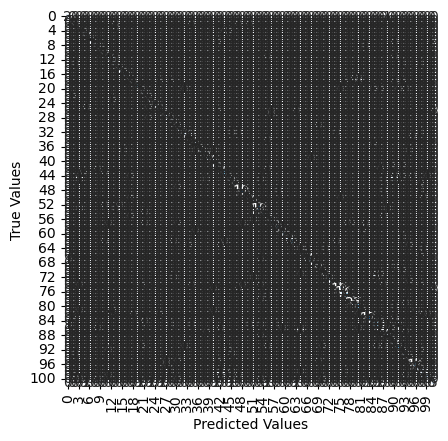

In [ ]:
test_rescal=ImageDataGenerator(rescale=1./255)
test_gen=test_rescal.flow_from_directory(
    directory=test_dir,                       
    target_size=(224, 224),          
    color_mode='rgb',                 
    class_mode='categorical',          
    batch_size=32,                  
    shuffle=False,
    seed=None,                      
  )
model_architecture = r"F:/Université de Toulouse/Je suis en France/Cours/S8/BE Apprentissage automatique (Machine learning)/Projet/Etapes de projet/model_flower.json"
model_weights = r"F:/Université de Toulouse/Je suis en France/Cours/S8/BE Apprentissage automatique (Machine learning)/Projet/Etapes de projet/model_flower.weights.h5"
model = model_from_json(open(model_architecture).read())
model.load_weights(model_weights)
model.summary()
y_pred_prob=model.predict(test_gen)
y_pred=np.argmax(y_pred_prob, 1)
labels = test_gen.classes
mat=confusion_matrix(labels, y_pred)
print(mat)
print(classification_report(labels, y_pred))
sns.heatmap(mat.T, square=True, annot=True, cbar=False, cmap=plt.cm.Blues,
fmt='.0f')
plt.xlabel('Predicted Values')
plt.ylabel('True Values')
plt.show()

- Obtenir les prédictions du modèle sur les données de test.
- Comparer ces prédictions aux étiquettes vraies.
- Afficher :<br>
        - Une matrice de confusion<br>
        - Un rapport de classification<br>
        - Une visualisation (heatmap) claire des erreurs.<br>

## 7. Sauvegarder le modèle pour le réutiliser plus tard

In [ ]:
model_json = model.to_json()
with open('model_flower.json', 'w') as json_file:
    json_file.write(model_json)
    model.save_weights('model_flower.weights.h5')

- Cela te permet de ne pas réentraîner le modèle à chaque fois et de le charger plus tard pour faire des prédictions ou le déployer dans une appli web (comme nous allons faire).

## Visualisation des filtres et activations dans VGG16

Nous avons utilisé le modèle VGG16 pré-entraîné pour observer :

- les filtres appris dans la première couche convolutionnelle,
- les activations (feature maps) produites par ces filtres,
- la classe prédite pour une image donnée.

L’objectif est de mieux comprendre comment le réseau décompose l’image à différents niveaux. Les premiers filtres détectent principalement des motifs simples comme les contours ou les zones de couleur, tandis que les activations montrent la réponse spatiale du réseau à ces motifs.

Cela permet d’interpréter partiellement le fonctionnement interne du réseau de neurones.


In [ ]:
import splitfolders
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import model_from_json
import cv2

## 8. Chargement du modèle

In [ ]:
model_architecture = r"F:/Université de Toulouse/Je suis en France/Cours/S8/BE Apprentissage automatique (Machine learning)/Projet/Etapes de projet/model_flower.json"
model_weights = r"F:/Université de Toulouse/Je suis en France/Cours/S8/BE Apprentissage automatique (Machine learning)/Projet/Etapes de projet/model_flower.weights.h5"
#model_architecture = 'model_flower.json'
#model_weights = 'model_flower.weights.h5'
model = model_from_json(open(model_architecture).read())
model.load_weights(model_weights)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │    25,691,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 102)            │        26,214 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,554,740 (375.96 MB)

 Trainable params: 28,733,286 (109.61 MB)

 Non-trainable params: 12,354,880 (47.13 MB)

 Optimizer params: 57,466,574 (219.22 MB)

## 9. Visualisation des filtres appris

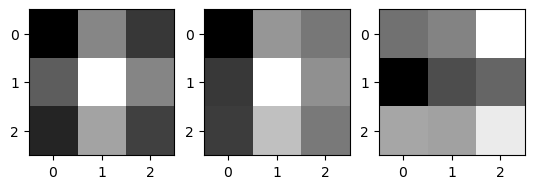

In [ ]:
base_model=model.layers[0]
# Example (visualiser le filtre numéro 2 appris par le modèle VGG16 )
# Récupérer les filtres et les poids de la 1ère couche
filters, biases, *is_anything_else_being_returned = base_model.layers[1].get_weights()
# normaliser les filtres sur [0 , 1]
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)
# Prendre le deuxième filtre de cette couche (qui contient 3 sous-filtres pour les 3 canaux R, V et B) et visualiser ces 3 sous-filtres
f=filters[:,:,:,1]
plt.subplot(1,3,1)
plt.imshow(f[:, :, 0], cmap='gray')
plt.subplot(1,3,2)
plt.imshow(f[:, :, 1], cmap='gray')
plt.subplot(1,3,3)
plt.imshow(f[:, :, 2], cmap='gray')

## 10. Visualiser les feature maps produites par la deuxième couche

Model: "functional_253"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,792 (7.00 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,792 (7.00 KB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


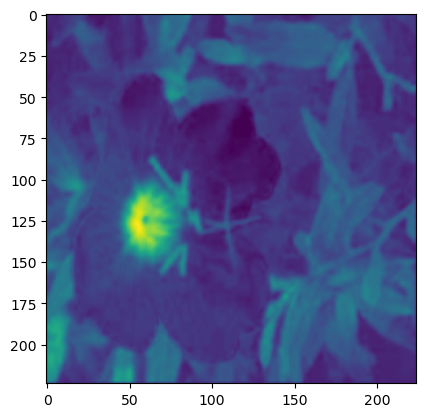

In [ ]:
# Example 2
# Définir un modèle intermédiaire contenant les 2 premières couches du modèle initial
from keras.models import Model
file= 'F:/Université de Toulouse/Je suis en France/Cours/S8/BE Apprentissage automatique (Machine learning)/Projet/flower_output/train/flower_01/image_06735.jpg'
image=Image.open(file)
image = np.asarray(image)
image=image.astype('float32')
image=cv2.resize(image,(224,224))
image /= 255
image = image.reshape([-1,224,224,3])
inter_model = Model(inputs=base_model.inputs, outputs=base_model.layers[1].output)
inter_model.summary()
feature_maps = inter_model.predict(image)
plt.imshow(feature_maps[0,:,:,1]) #♀ Si on change le 1 le filtre change

## 11. Prédiction finale

In [ ]:
proba=model.predict(image)
pred_classe=np.argmax(proba, 1)
print("Classe =", pred_classe)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 564ms/step
Classe = [0]


## 12. La création d’une API avec Streamlit de classification de fleurs
- Dans cette dernière étape du projet, nous avons développé une interface utilisateur avec Streamlit, permettant de téléverser une image de fleur et d’obtenir automatiquement sa classe prédite (le type de fleur) ainsi que la probabilité associée.
- Le modèle VGG16 pré-entraîné est chargé au démarrage de l'application. Lorsqu'une image est sélectionnée, elle est redimensionnée, normalisée et analysée par le modèle. Le nom de la fleur prédite est ensuite affiché dynamiquement dans l’interface.
- Cette interface représente la version interactive et accessible du modèle entraîné, comparable à un mini-site web de démonstration.

In [ ]:
import streamlit as st
import numpy as np
import cv2
from tensorflow.keras.models import model_from_json

- **Liste des noms de classes**<br>
  $-$ C’est une liste de 102 noms de fleurs. Chaque index (0, 1, 2, ...) correspond à une classe prédite par le modèle.

In [ ]:
nom_classe= ['pink, primrose', 'hard-leaved, pocket, orchid','canterbury, bells', 'sweet, pea', 'english, marigold', 
             'tiger, lily', 'moon, orchid', 'bird, of, paradise','monkshood', 'globe, thistle', 'snapdragon', "colt's, foot", 
             'king, protea', 'spear, thistle', 'yellow, iris','globe-flower', 'purple, coneflower', 'peruvian, lily', 
             'balloon, flower', 'giant, white, arum, lily', 'fire, lily','pincushion, flower', 'fritillary', 'red, ginger', 'grape, hyacinth', 
             'corn, poppy', 'prince, of, wales, feathers', 'stemless, gentian','artichoke', 'sweet, william', 'carnation', 'garden, phlox', 
             'love, in, the, mist', 'mexican, aster', 'alpine, sea, holly','ruby-lipped, cattleya', 'cape, flower', 'great, masterwort', 
             'siam, tulip', 'lenten, rose', 'barbeton, daisy', 'daffodil', 'sword, lily', 'poinsettia', 'bolero, deep, blue', 'wallflower', 
             'marigold', 'buttercup', 'oxeye, daisy', 'common, dandelion', 'petunia', 'wild, pansy', 'primula', 'sunflower', 'pelargonium', 
             'bishop, of, llandaff', 'gaura', 'geranium', 'orange, dahlia', 'pink-yellow, dahlia', 'cautleya, spicata', 'japanese, anemone', 
             'black-eyed, susan', 'silverbush', 'californian, poppy', 'osteospermum', 'spring, crocus', 'bearded, iris', 'windflower', 
             'tree, poppy', 'gazania', 'azalea', 'water, lily', 'rose', 'thorn, apple', 'morning, glory', 'passion, flower', 'lotus, lotus', 
             'toad, lily','anthurium', 'frangipani', 'clematis', 'hibiscus', 'columbine', 'desert-rose', 'tree, mallow', 'magnolia', 
             'cyclamen', 'watercress', 'canna, lily', 'hippeastrum', 'bee, balm', 'ball, moss', 'foxglove', 'bougainvillea', 'camellia', 'mallow', 
             'mexican, petunia', 'bromelia', 'blanket, flower', 'trumpet, creeper', 'blackberry, lily']


- **Fonction de chargement du modèle**

In [ ]:
@st.cache_data
def load_model():
    model_architecture = r"F:/Université de Toulouse/Je suis en France/Cours/S8/BE Apprentissage automatique (Machine learning)/Projet/Etapes de projet/model_flower.json"
    model_weights = r"F:/Université de Toulouse/Je suis en France/Cours/S8/BE Apprentissage automatique (Machine learning)/Projet/Etapes de projet/model_flower.weights.h5"
    #model_architecture = 'model_flower.json'
    #model_weights = 'model_flower.weights.h5'
    model = model_from_json(open(model_architecture).read())
    model.load_weights(model_weights)  
    return model
with st.spinner('Model is being loaded..'):
  model=load_model()

2025-05-11 23:45:58.584 No runtime found, using MemoryCacheStorageManager


- **Titre de l’application**

In [ ]:
st.write("""
         # Classification des fleurs """
         )

- **Zone pour téléverser une image**

In [ ]:
file = st.file_uploader("Upload the image to be classified", type=["jpg", "png", "jpeg"])
#st.set_option('deprecation.showfileUploaderEncoding', False)

- **Fonction qui prépare l’image + prédit**

In [ ]:
def upload_predict(image, model):  
        image = np.asarray(image)
        image=image.astype('float32')
        image=cv2.resize(image,(224,224))
        image /= 255
        image = image.reshape([-1,224,224,3])
        prediction = model.predict(image)
        pred_class=np.argmax(prediction, axis=1)       
        return pred_class, prediction

- **Traitement de l’image envoyée**

In [ ]:
if file is None:
    st.text("Please upload an image file")
else:
    image = Image.open(file)
    st.image(image, use_column_width=True)
    pred_class, prediction = upload_predict(image, model)
    st.write("The image is classified as",nom_classe[pred_class[0]])
    st.write("The probability is", prediction[0][pred_class[0]])

## 13. Interface utilisateur pour la classification d’images
- Pour lancer l’application web (API), il suffit d’exécuter la commande suivante dans l’environnement **$Streamlit$_$BE$** depuis Anaconda Prompt :<br>
  **streamlit run BE_partie_6.py**<br>
- Une fois l’application ouverte dans le navigateur, il est possible de téléverser n’importe quelle image de fleur, et le modèle pré-entraîné affichera automatiquement :<br>
        $-$ la classe prédite (nom de la fleur),<br>
        $-$ ainsi que la probabilité associée à cette prédiction.